In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [3]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
# patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
patch_label_df = pd.read_csv(os.path.join(root_dir,"patch_label_df_FAclass_position_GB_pred.csv"))
lat8_margaret_label_121922 = pd.read_csv(os.path.join(root_dir, 'lat8_margaret_label_121922.csv'))

latents_lat8_2d = joblib.load(os.path.join(root_dir, "pax_wholecell_data_latents_lat8_2d.pkl"))



In [4]:
# choose the combinations you want to display (use your real label strings)
keep_combos = {
    ("Cell Protruding Edge", "Nascent Adhesion"),
    ("Cell Protruding Edge",  "focal complex"),
    ("Cell Periphery/other",  "focal complex"),
    ("Lamella",  "focal complex"),
    ("Cell Protruding Edge",  "focal adhesion"),
    ("Cell Periphery/other",  "focal adhesion"),
    ("Cell Body",  "fibrillar adhesion"),     
    ("Lamella",  "focal adhesion"),  
    ("Cell Periphery/other",  "No adhesion"),  
    ("Lamella",  "No adhesion"),  
    ("Cell Body",  "No adhesion"),  
    # add more...
}

df = lat8_margaret_label_121922.copy()

df["joint_label"] = (
    df["Position"].astype(str).str.strip()
    + " | "
    + df["classification"].astype(str).str.strip()
)

keep_joint_labels = {
    f"{p} | {f}"
    for p, f in keep_combos
}

df_keep = df[df["joint_label"].isin(keep_joint_labels)].copy()



In [5]:
keep_joint_labels

{'Cell Body | No adhesion',
 'Cell Body | fibrillar adhesion',
 'Cell Periphery/other | No adhesion',
 'Cell Periphery/other | focal adhesion',
 'Cell Periphery/other | focal complex',
 'Cell Protruding Edge | Nascent Adhesion',
 'Cell Protruding Edge | focal adhesion',
 'Cell Protruding Edge | focal complex',
 'Lamella | No adhesion',
 'Lamella | focal adhesion',
 'Lamella | focal complex'}

In [6]:
tab10_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#17becf", "#bcbd22", "#032b60",
    "#ffff78",
]

In [7]:

joint_labels_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(keep_joint_labels)
}

joint_label_to_id = {
    cls: i
    for i, cls in enumerate(keep_joint_labels)
}

df_keep["joint_label_id"] = (
    df_keep["joint_label"]
        .map(joint_label_to_id)
)

In [8]:
joint_label_to_id

{'Cell Periphery/other | focal adhesion': 0,
 'Lamella | focal adhesion': 1,
 'Cell Protruding Edge | focal complex': 2,
 'Cell Periphery/other | focal complex': 3,
 'Cell Body | fibrillar adhesion': 4,
 'Cell Protruding Edge | Nascent Adhesion': 5,
 'Lamella | focal complex': 6,
 'Lamella | No adhesion': 7,
 'Cell Body | No adhesion': 8,
 'Cell Periphery/other | No adhesion': 9,
 'Cell Protruding Edge | focal adhesion': 10}

In [45]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]

position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]
fa_label_to_id = {
    label: i
    for i, label in enumerate(classification_label_order)
}

position_label_to_id = {
    label: i
    for i, label in enumerate(position_label_order)
}
id_to_joint_label = {
    v: k
    for k, v in joint_label_to_id.items()
}


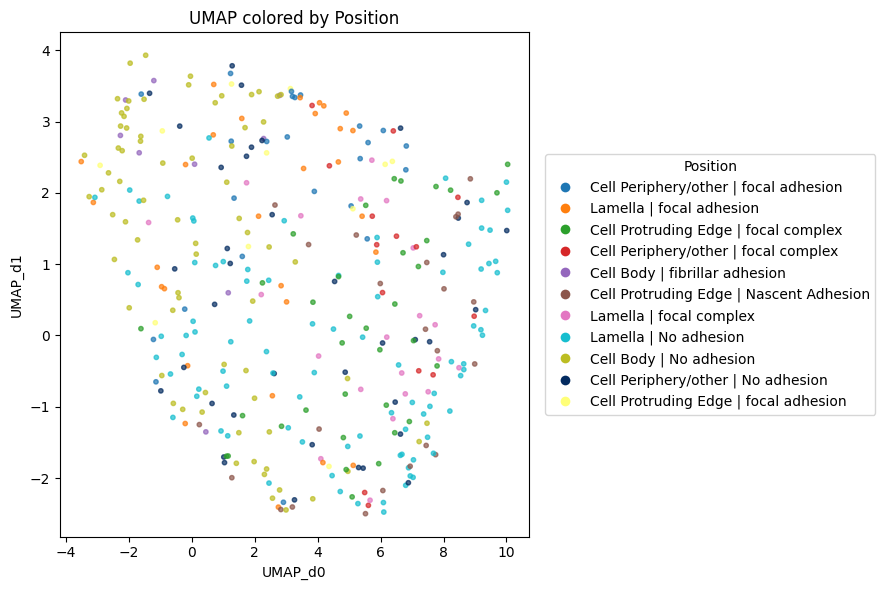

In [9]:
plt.figure(figsize=(9, 6))

# plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    df_keep["UMAP_d0"],
    df_keep["UMAP_d1"],
    c=df_keep["joint_label"].map(joint_labels_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


In [10]:
lat_cols = [f"lat_d{i}" for i in range(8)]


X = df_keep[lat_cols].values
y_jointlabel = df_keep["joint_label"].values
y_jointlabel_enc = df_keep["joint_label_id"].values



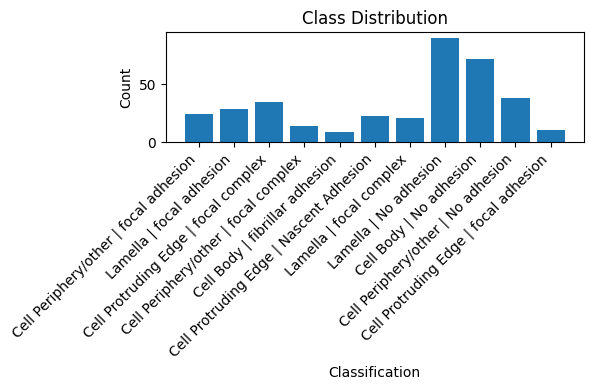

In [11]:
import matplotlib.pyplot as plt
import numpy as np

class_names = joint_labels_to_color
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    y_jointlabel_enc,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Classification")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()


In [12]:
indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_jointlabel_enc,   # primary task
    random_state=42
)

X_train = X[train_idx]
X_val   = X[val_idx]

y_jointlabel_train = y_jointlabel_enc[train_idx]
y_jointlabel_val   = y_jointlabel_enc[val_idx]



In [13]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])


In [14]:
pipe.fit(X_train, y_jointlabel_train)


/home/ldin/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [15]:
y_jointlabel_pred_val = pipe.predict(X_val)

print("Validation classification report:")
print(classification_report(
    y_jointlabel_val,
    y_jointlabel_pred_val,
    target_names=joint_labels_to_color
))


Validation classification report:
                                         precision    recall  f1-score   support

  Cell Periphery/other | focal adhesion       0.00      0.00      0.00         5
               Lamella | focal adhesion       0.00      0.00      0.00         6
   Cell Protruding Edge | focal complex       0.00      0.00      0.00         7
   Cell Periphery/other | focal complex       0.00      0.00      0.00         3
         Cell Body | fibrillar adhesion       0.09      0.50      0.15         2
Cell Protruding Edge | Nascent Adhesion       0.15      0.40      0.22         5
                Lamella | focal complex       0.11      0.25      0.15         4
                  Lamella | No adhesion       0.08      0.06      0.07        18
                Cell Body | No adhesion       0.54      0.50      0.52        14
     Cell Periphery/other | No adhesion       0.25      0.12      0.17         8
  Cell Protruding Edge | focal adhesion       0.00      0.00      0.00    

/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
cm = confusion_matrix(y_jointlabel_val,    y_jointlabel_pred_val,)

cm_df = pd.DataFrame(
    cm,
    index=joint_labels_to_color,
    columns=joint_labels_to_color
)

cm_df


,Cell Periphery/other | focal adhesion,Lamella | focal adhesion,Cell Protruding Edge | focal complex,Cell Periphery/other | focal complex,Cell Body | fibrillar adhesion,Cell Protruding Edge | Nascent Adhesion,Lamella | focal complex,Lamella | No adhesion,Cell Body | No adhesion,Cell Periphery/other | No adhesion,Cell Protruding Edge | focal adhesion
Cell Periphery/other | focal adhesion,0,0,0,0,0,0,0,2,1,0,2
Lamella | focal adhesion,2,0,0,0,2,0,0,2,0,0,0
Cell Protruding Edge | focal complex,0,1,0,2,0,2,1,1,0,0,0
Cell Periphery/other | focal complex,2,0,0,0,0,0,0,1,0,0,0
Cell Body | fibrillar adhesion,0,0,0,0,1,0,0,0,1,0,0
Cell Protruding Edge | Nascent Adhesion,0,0,0,1,0,2,2,0,0,0,0
Lamella | focal complex,0,0,0,0,0,2,1,1,0,0,0
Lamella | No adhesion,0,0,0,0,2,4,5,1,3,2,1
Cell Body | No adhesion,0,0,0,0,2,1,0,3,7,1,0
Cell Periphery/other | No adhesion,0,0,0,0,2,2,0,1,1,1,1


In [17]:
coef = pd.DataFrame(
    pipe.named_steps["clf"].coef_,
    columns=lat_cols,
    index=joint_labels_to_color
)

coef


,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
Cell Periphery/other | focal adhesion,0.392250,0.990337,0.118336,-0.547085,-0.038079,0.308942,-0.046807,0.019357
Lamella | focal adhesion,0.333673,0.149359,0.097190,-0.273602,-0.131902,0.396694,0.407943,0.228672
Cell Protruding Edge | focal complex,-0.051061,-0.442727,-0.271163,0.150857,-0.261108,0.517780,-0.216903,-0.265065
Cell Periphery/other | focal complex,0.295867,-0.284416,-0.623989,0.580681,0.376206,1.305927,0.777811,-1.199133
Cell Body | fibrillar adhesion,0.455780,0.605754,0.145209,-0.309960,-0.106123,-0.751283,1.293032,0.174789
Cell Protruding Edge | Nascent Adhesion,-0.265504,-0.997337,-0.598910,0.361816,-0.162130,-0.261600,-0.646157,-0.234314
Lamella | focal complex,-0.277317,-0.547992,0.205648,0.746556,-0.554217,0.199700,-0.346148,0.420398
Lamella | No adhesion,-0.353714,-0.659562,-0.208555,0.363173,0.157933,-0.750017,-0.879139,0.447608
Cell Body | No adhesion,0.034116,0.028156,0.210227,-0.360723,0.015394,-0.591632,0.581745,0.565425
Cell Periphery/other | No adhesion,-0.098597,0.007285,0.228816,-0.264145,0.321666,0.018774,-0.646439,-0.010074


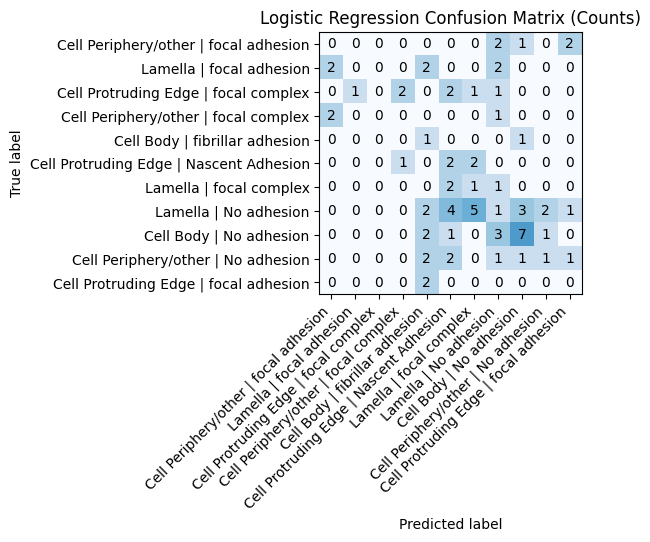

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),  cmap="Blues",vmax=4.5)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Logistic Regression Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


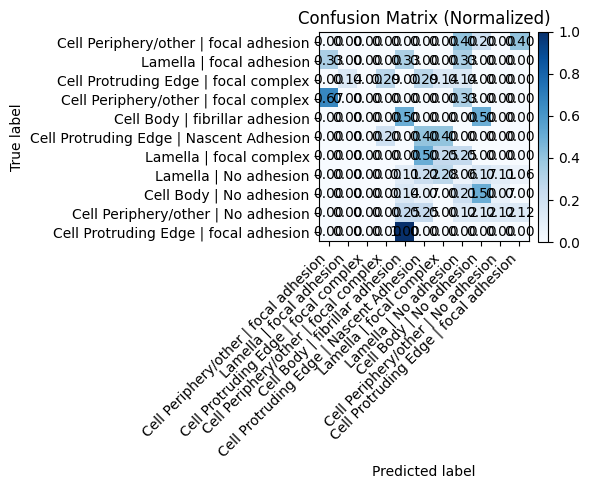

In [19]:
from matplotlib.colors import PowerNorm

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 6))


im = ax.imshow(
    cm_norm,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Normalized)")

# annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [20]:
np.sqrt(cm)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.41421356, 1.        , 0.        ,
        1.41421356],
       [1.41421356, 0.        , 0.        , 0.        , 1.41421356,
        0.        , 0.        , 1.41421356, 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , 1.41421356, 0.        ,
        1.41421356, 1.        , 1.        , 0.        , 0.        ,
        0.        ],
       [1.41421356, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 1.        , 0.        ,
        1.41421356, 1.41421356, 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

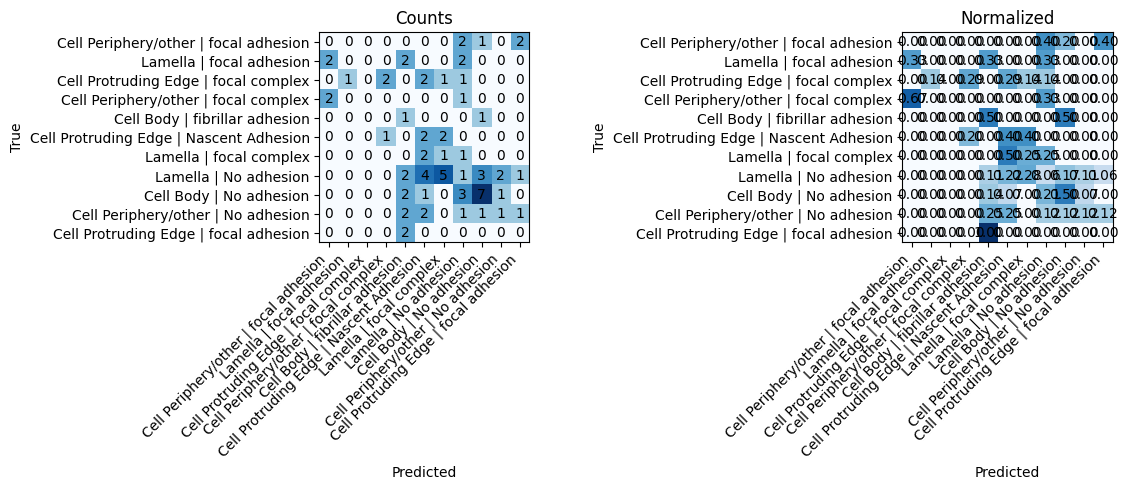

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(
    axes,
    [cm, cm_norm],
    ["Counts", "Normalized"]
):
    im = ax.imshow(np.sqrt(mat),   cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = mat[i, j] if title == "Counts" else f"{mat[i, j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [22]:
y_jointlabel_train_pred = pipe.predict(X_train)
print("Train accuracy:", (y_jointlabel_train_pred == y_jointlabel_train).mean())


Train accuracy: 0.2876712328767123


# Logistic regression cannot separate samples
Try other higher level ones

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_jointlabel_train)

y_jointlabel_val_pred = rf.predict(X_val)
print(classification_report(y_jointlabel_val, y_jointlabel_val_pred, target_names=joint_labels_to_color))


                                         precision    recall  f1-score   support

  Cell Periphery/other | focal adhesion       0.20      0.20      0.20         5
               Lamella | focal adhesion       0.00      0.00      0.00         6
   Cell Protruding Edge | focal complex       0.50      0.43      0.46         7
   Cell Periphery/other | focal complex       0.00      0.00      0.00         3
         Cell Body | fibrillar adhesion       0.00      0.00      0.00         2
Cell Protruding Edge | Nascent Adhesion       0.00      0.00      0.00         5
                Lamella | focal complex       0.00      0.00      0.00         4
                  Lamella | No adhesion       0.27      0.33      0.30        18
                Cell Body | No adhesion       0.29      0.50      0.37        14
     Cell Periphery/other | No adhesion       1.00      0.12      0.22         8
  Cell Protruding Edge | focal adhesion       0.00      0.00      0.00         2

                          

/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
cm = confusion_matrix(y_jointlabel_val, y_jointlabel_pred_val)
class_names = joint_labels_to_color


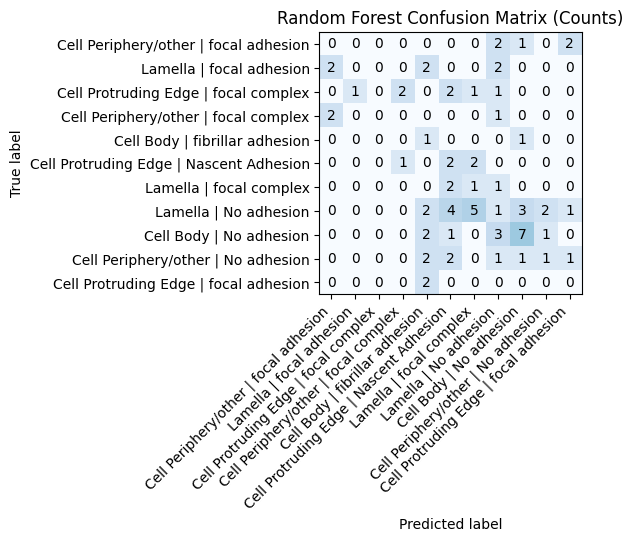

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),    cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [72]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 68.5 MB/s  0:00:01m0:00:0100:01


In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import numpy as np

# If you have imbalance, this often helps; otherwise you can remove it.
# XGB doesn't have class_weight="balanced" like sklearn, but you can pass sample_weight.
# For now we'll keep it simple.

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="multi:softmax",      # direct class prediction
    num_class=len(joint_label_to_id),  # IMPORTANT: set to number of classes
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_jointlabel_train)

y_jointlabel_train_pred = xgb.predict(X_train)
y_jointlabel_pred_val = xgb.predict(X_val)

print(classification_report(
    y_jointlabel_val,
    y_jointlabel_pred_val,
    target_names=joint_label_to_id
))


                                         precision    recall  f1-score   support

  Cell Periphery/other | focal adhesion       0.17      0.20      0.18         5
               Lamella | focal adhesion       0.00      0.00      0.00         6
   Cell Protruding Edge | focal complex       0.40      0.29      0.33         7
   Cell Periphery/other | focal complex       0.00      0.00      0.00         3
         Cell Body | fibrillar adhesion       0.00      0.00      0.00         2
Cell Protruding Edge | Nascent Adhesion       0.33      0.20      0.25         5
                Lamella | focal complex       0.00      0.00      0.00         4
                  Lamella | No adhesion       0.38      0.56      0.45        18
                Cell Body | No adhesion       0.36      0.36      0.36        14
     Cell Periphery/other | No adhesion       0.29      0.25      0.27         8
  Cell Protruding Edge | focal adhesion       0.00      0.00      0.00         2

                          

/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [77]:
X_all = patch_label_df[lat_cols].values

y_jointlabel_all_pred = xgb.predict(X_all)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_jointlabel_train)

y_jointlabel_train_pred = gb.predict(X_train)

y_jointlabel_pred_val = gb.predict(X_val)
print(classification_report(y_jointlabel_val, y_jointlabel_pred_val, target_names=joint_labels_to_color))


                                         precision    recall  f1-score   support

  Cell Periphery/other | focal adhesion       0.00      0.00      0.00         5
               Lamella | focal adhesion       0.00      0.00      0.00         6
   Cell Protruding Edge | focal complex       0.33      0.14      0.20         7
   Cell Periphery/other | focal complex       0.00      0.00      0.00         3
         Cell Body | fibrillar adhesion       0.00      0.00      0.00         2
Cell Protruding Edge | Nascent Adhesion       0.00      0.00      0.00         5
                Lamella | focal complex       0.00      0.00      0.00         4
                  Lamella | No adhesion       0.37      0.61      0.46        18
                Cell Body | No adhesion       0.31      0.36      0.33        14
     Cell Periphery/other | No adhesion       0.00      0.00      0.00         8
  Cell Protruding Edge | focal adhesion       0.00      0.00      0.00         2

                          

/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


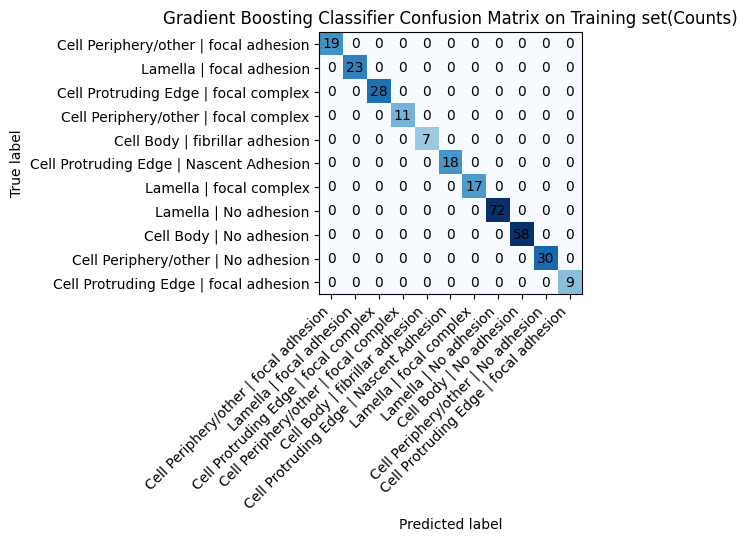

In [70]:
cm = confusion_matrix(y_jointlabel_train, y_jointlabel_train_pred)
class_names = joint_labels_to_color
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix on Training set(Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


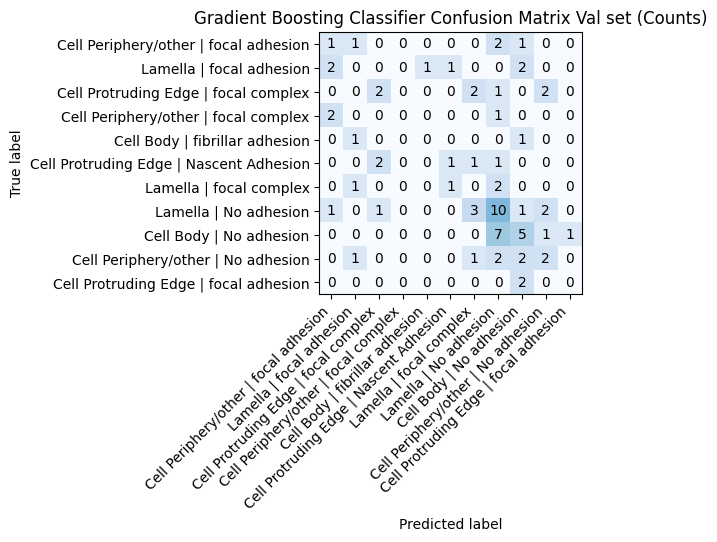

In [74]:

cm = confusion_matrix(y_jointlabel_val, y_jointlabel_pred_val)
class_names = joint_labels_to_color
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix Val set (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [30]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X_all = patch_label_df[lat_cols].values
umap_all_d0 = patch_label_df['UMAP_d0']
umap_all_d1 = patch_label_df['UMAP_d1']
front_flag_all = patch_label_df['front_flag']

y_jointlabel_all_pred = gb.predict(X_all)

In [31]:
front_flag_all = patch_label_df['front_flag']

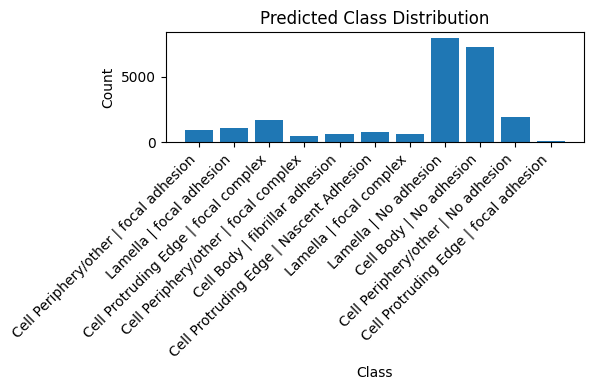

In [32]:

class_names = joint_labels_to_color
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    y_jointlabel_all_pred,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


In [33]:
# id -> color (via label)
fa_id_to_color = {
    i: joint_labels_to_color[label]
    for i, label in enumerate(joint_labels_to_color)
}

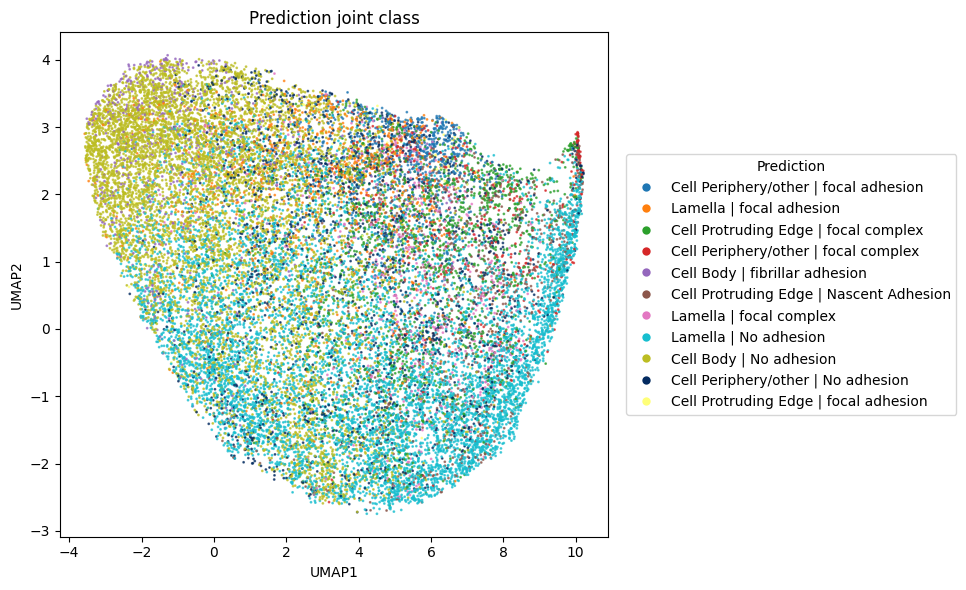

In [34]:
# plot the predictions with Gradient Boosting Classifier
mask = y_jointlabel_all_pred > -1

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction joint class")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



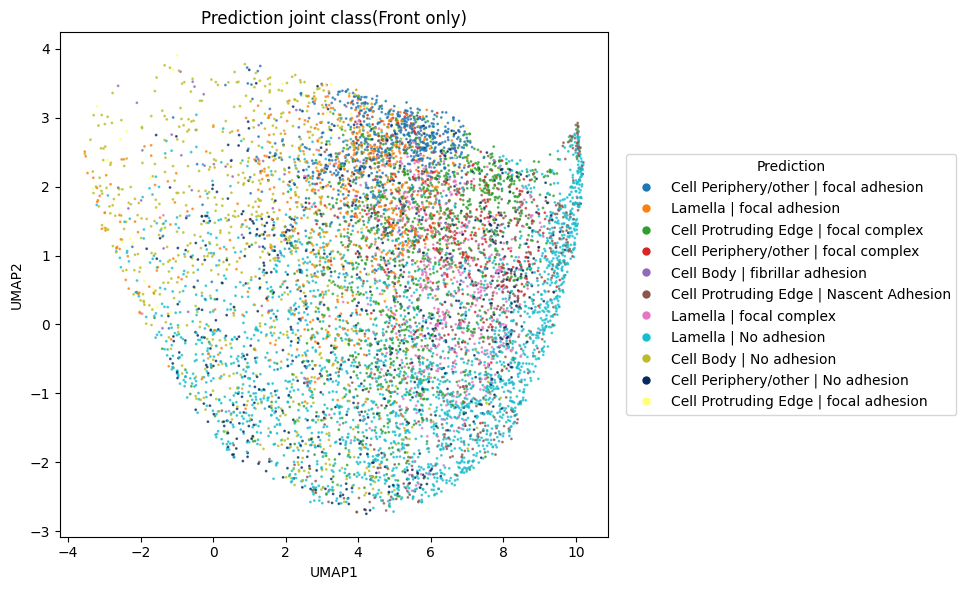

In [78]:

mask = front_flag_all > 0

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Prediction joint class(Front only)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



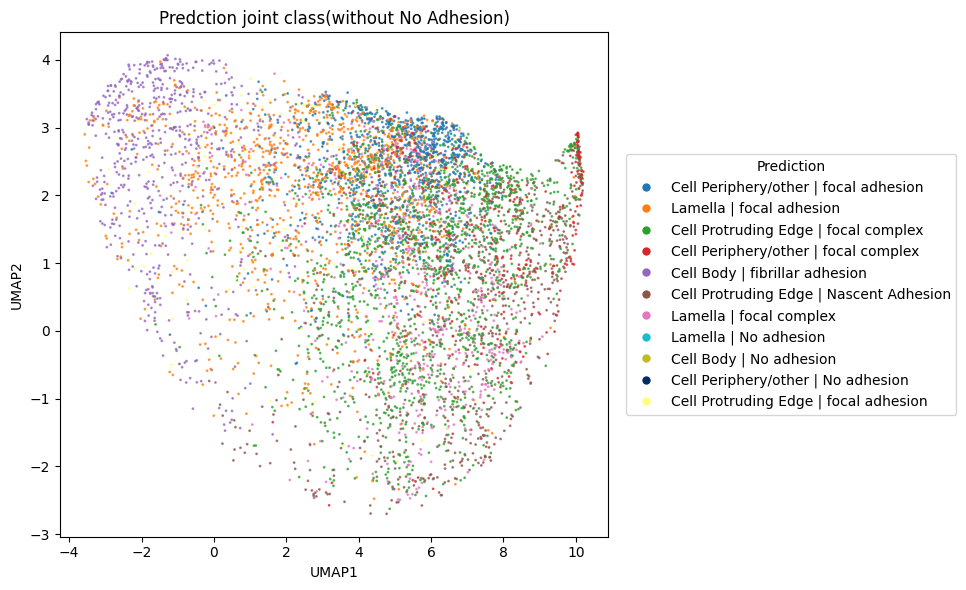

In [37]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8)

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction joint class(without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [38]:
joint_labels_to_color

{'Cell Periphery/other | focal adhesion': '#1f77b4',
 'Lamella | focal adhesion': '#ff7f0e',
 'Cell Protruding Edge | focal complex': '#2ca02c',
 'Cell Periphery/other | focal complex': '#d62728',
 'Cell Body | fibrillar adhesion': '#9467bd',
 'Cell Protruding Edge | Nascent Adhesion': '#8c564b',
 'Lamella | focal complex': '#e377c2',
 'Lamella | No adhesion': '#17becf',
 'Cell Body | No adhesion': '#bcbd22',
 'Cell Periphery/other | No adhesion': '#032b60',
 'Cell Protruding Edge | focal adhesion': '#ffff78'}

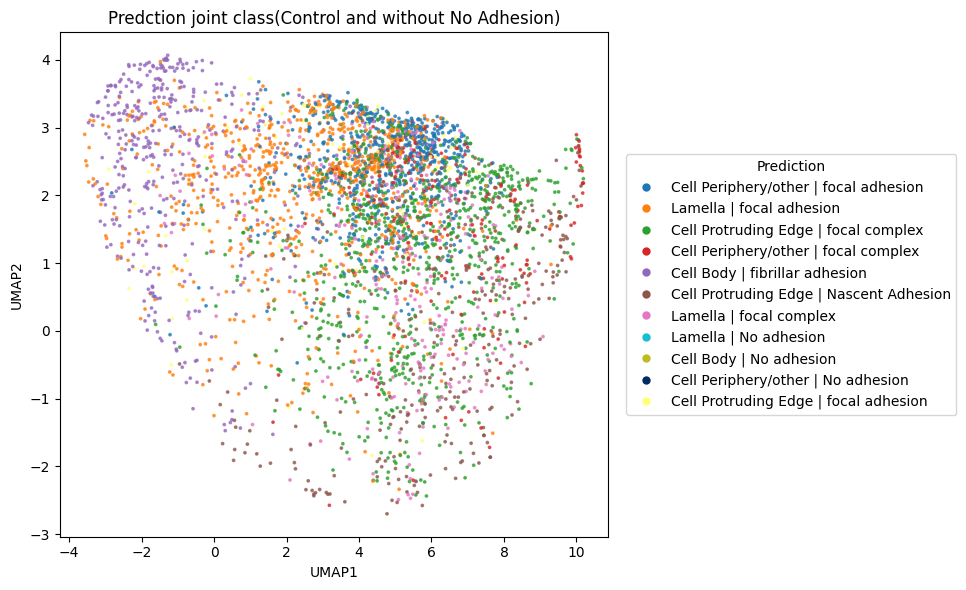

In [39]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), patch_label_df['group'].values == 'control')

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction joint class(Control and without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



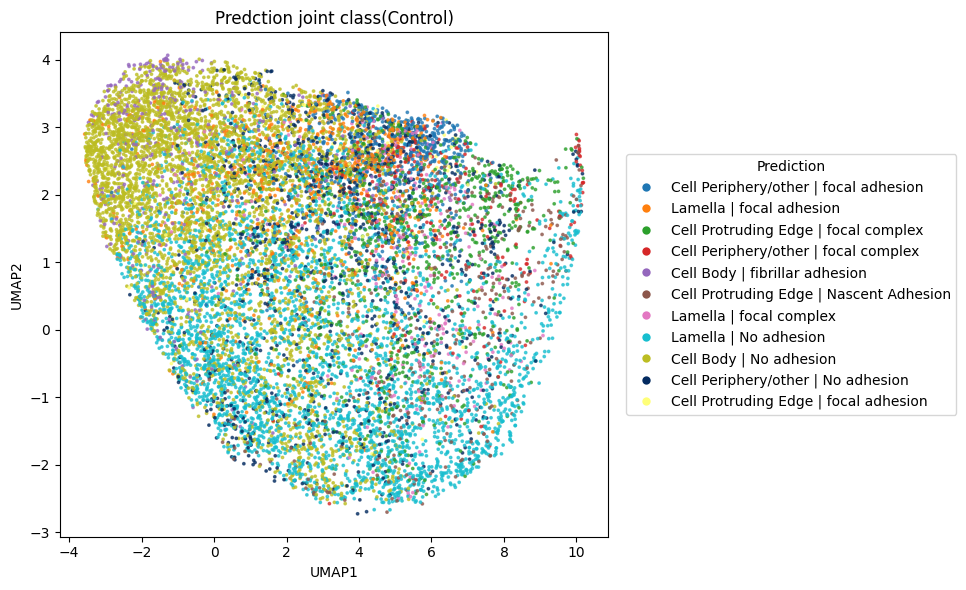

In [75]:
# plot without the  "no adhesion group"
mask = patch_label_df['group'].values == 'control'

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction joint class(Control)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [80]:
# plot without the  "no adhesion group"
# mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
#                          y_jointlabel_enc!=7),y_jointlabel_enc!=8), df_keep['group'].values == 'control')
mask = df_keep['group'].values == 'control'

pred_ids = y_jointlabel_all_pred[mask]


plt.figure(figsize=(8, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Pred Class Distribution(Control)")
plt.ylim([0,90])
plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along dimension 0; dimension is 23656 but corresponding boolean dimension is 366

In [44]:
counts

array([271., 276., 833., 244., 245., 452., 308.,   0.,   0.,   0.,  37.])

In [ ]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), patch_label_df['group'].values == 'control')

pred_ids = y_jointlabel_all_pred[mask]


plt.figure(figsize=(8, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)
count_joint = np.zeros(4,5)

# count_joint[0,0] = 

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Prediction Class Distribution(Control)")
plt.ylim([0,2000])
plt.tight_layout()
plt.show()

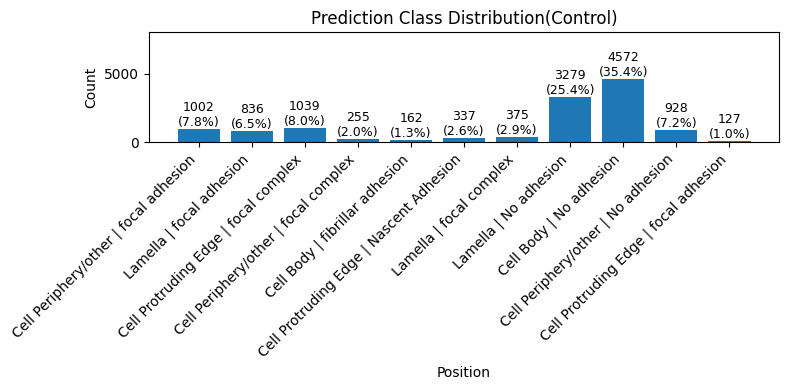

In [82]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), patch_label_df['group'].values == 'control')
mask = patch_label_df['group'].values == 'control'

pred_ids = y_jointlabel_all_pred[mask]


plt.figure(figsize=(8, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Prediction Class Distribution(Control)")

plt.ylim([0,8000])
plt.tight_layout()
plt.show()

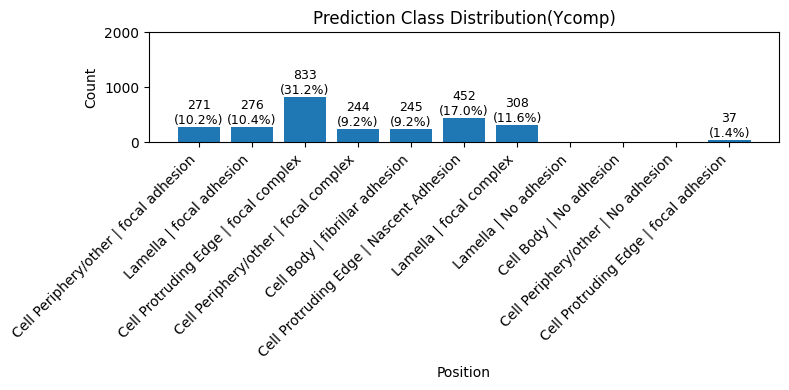

In [42]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), patch_label_df['group'].values == 'ycomp')

pred_ids = y_jointlabel_all_pred[mask]


plt.figure(figsize=(8, 4))

counts, bins, patches = plt.hist(
    pred_ids,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

total = counts.sum()

# Add percentage labels
for count, patch in zip(counts, patches):
    if count > 0:
        percentage = 100 * count / total
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        # inside the same loop
        plt.text(
            x, y,
            f"{int(count)}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Position")
plt.ylabel("Count")
plt.title("Prediction Class Distribution(Ycomp)")
plt.ylim([0,2000])
plt.tight_layout()
plt.show()

In [46]:
joint_id_to_info = {}

for joint_id, joint_label in id_to_joint_label.items():
    position, fa = [s.strip() for s in joint_label.split("|")]

    joint_id_to_info[joint_id] = {
        "joint_label": joint_label,        
        "position_label": position,
        "fa_label": fa,
        "position_id": position_label_to_id[position],
        "fa_id": fa_label_to_id[fa],
    }


In [84]:
pos_pred_ids = np.array([joint_id_to_info[j]["position_id"] for j in y_jointlabel_all_pred])
fa_pred_ids  = np.array([joint_id_to_info[j]["fa_id"] for j in y_jointlabel_all_pred])


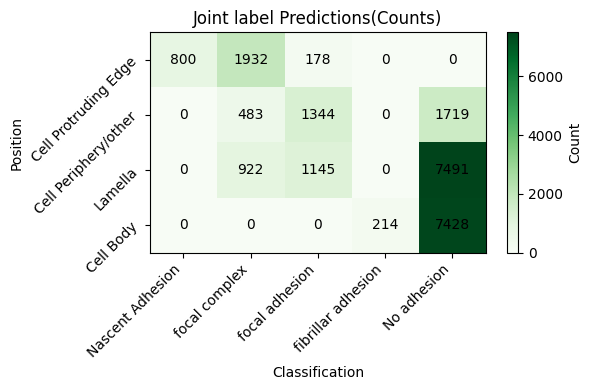

In [87]:
mask = patch_label_df["group"] !='dfdsaf'


ct_pred = pd.crosstab(
    pos_pred_ids[mask], fa_pred_ids[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Joint label Predictions(Counts)")

# annotate cells
for i in range(ct_pred.shape[0]):
    for j in range(ct_pred.shape[1]):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [ ]:
def FA_pos_2D_counts_plot(mask,pos_pred_ids,fa_pred_ids,classification_label_order) 
mask = patch_label_df["group"] !='dfdsaf'


ct_pred = pd.crosstab(
    pos_pred_ids[mask], fa_pred_ids[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Joint label Predictions(Counts)")

# annotate cells
for i in range(ct_pred.shape[0]):
    for j in range(ct_pred.shape[1]):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [91]:
patch_label_df['jointlabel_based_pred'] = y_jointlabel_all_pred

patch_label_df.to_csv(os.path.join(root_dir,"patch_label_df_FAclass_position_joint_GB_pred.csv"))

In [154]:
df_train_val_flag = pd.read_csv(os.path.join(root_dir,"df_train_val_flag.csv"))

In [155]:
df_train_val_flag

,Unnamed: 0,crop_img_filename,train_val_flag,group_ID,group,unique_ID
0,0,f0037x0624y0816ps32.tif,3,0,control,control-f0037x0624y0816ps32.tif
1,1,f0039x0208y0464ps32.tif,3,1,ycomp,ycomp-f0039x0208y0464ps32.tif
2,2,f0002x0784y0656ps32.tif,3,0,control,control-f0002x0784y0656ps32.tif
3,3,f0019x0336y0496ps32.tif,3,0,control,control-f0019x0336y0496ps32.tif
4,4,f0030x0464y0784ps32.tif,3,0,control,control-f0030x0464y0784ps32.tif
...,...,...,...,...,...,...
23651,23651,f0003x0176y0432ps32.tif,4,1,ycomp,ycomp-f0003x0176y0432ps32.tif
23652,23652,f0013x0752y0496ps32.tif,4,1,ycomp,ycomp-f0013x0752y0496ps32.tif
23653,23653,f0045x0624y0624ps32.tif,4,0,control,control-f0045x0624y0624ps32.tif
23654,23654,f0020x0976y0688ps32.tif,4,0,control,control-f0020x0976y0688ps32.tif


In [156]:
df_train_val_flag.columns

Index(['Unnamed: 0', 'crop_img_filename', 'train_val_flag', 'group_ID',
       'group', 'unique_ID'],
      dtype='object')

In [151]:
patch_label_df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str',
       'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred'],
      dtype='object')

In [159]:
patch_label_df_trainval = pd.merge(patch_label_df,df_train_val_flag[['train_val_flag', 'group_ID',
        'unique_ID']],on='unique_ID',how='inner')

In [160]:
patch_label_df_trainval.columns


Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str',
       'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID'],
      dtype='object')

In [161]:
pax_MSE_df = pd.read_csv(os.path.join(root_dir,"pax_MSE_df.csv"))

In [162]:
patch_label_df_trainval.columns


Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str',
       'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID'],
      dtype='object')

In [163]:
pax_MSE_df.columns

Index(['Unnamed: 0', 'Unnamed: 0_x', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge_x', 'front_flag_x', 'Unnamed: 0.1', 'Unnamed: 0_y',
       'y_corner4', 'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3',
       'rand_ty', 'x_corner1', 'x_corner3', 'movie_partitioned_data_dir',
       'y_corner2', 'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir',
       'image_folder', 'rand_tx', 'filename', 'y_c', 'y_corner1',
       'dist_cell_edge_y', 'front_flag_y', 'group', 'unique_ID', 'AE_MSE'],
      dtype='object')

In [166]:
patch_label_df_trainval_MSE = pd.merge(patch_label_df_trainval,pax_MSE_df[['unique_ID', 'y_corner4', 'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3',
       'rand_ty', 'x_corner1', 'x_corner3', 'movie_partitioned_data_dir',
       'y_corner2', 'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir',
       'image_folder', 'rand_tx', 'filename', 'y_c', 'y_corner1','AE_MSE']],on='unique_ID')

In [168]:
patch_label_df_trainval_MSE.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str',
       'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID', 'y_corner4',
       'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3', 'rand_ty',
       'x_corner1', 'x_corner3', 'movie_partitioned_data_dir', 'y_corner2',
       'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir', 'image_folder',
       'rand_tx', 'filename', 'y_c', 'y_corner1', 'AE_MSE'],
      dtype='object')

In [170]:
patch_label_df_trainval_MSE.to_csv(os.path.join(root_dir,"patch_label_df_trainval_MSE_lesscol.csv"))

In [171]:
import hashlib
import numpy as np
import pandas as pd

def deterministic_weighted_sample_with_holdout(
    df: pd.DataFrame,
    seed_str: str,
    n: int = 1500,
    id_col: str = "crop_img_filename",
    group_col: str = "filename",
    holdout_frac: float = 0.25,   # last 25% of groups excluded
    # new columns for weighting
    fa_col: str = "FA_class_based_pred",
    pos_col: str = "position_based_pred",
    group_id_col: str = "group_ID",
    # weights
    high_weight: float = 10,
    low_weight: float = 1e-3,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Deterministic, reproducible, weighted sampling WITHOUT replacement,
    with a deterministic group-based holdout on df[group_col].

    Holdout:
      - Deterministically orders unique group_col values using seed_str
      - Keeps first (1-holdout_frac) groups eligible
      - Samples n rows only from eligible groups

    Weights (current rules):
      - weight = high_weight if (group_ID == 1 and FA_class_based_pred == 2)
      - weight = low_weight  if (FA_class_based_pred == 4)
      - else weight = 1.0
      - position_based_pred is currently neutral (no rule specified).
    """
    if not (0.0 <= holdout_frac < 1.0):
        raise ValueError("holdout_frac must be in [0, 1).")
    if n <= 0:
        raise ValueError("n must be > 0.")
    for col in [group_col, id_col, fa_col, pos_col, group_id_col]:
        if col not in df.columns:
            raise KeyError(f"Missing required column '{col}' in df.")

    df = df.copy()

    def md5_int(s: str) -> int:
        return int(hashlib.md5(s.encode()).hexdigest(), 16)

    # 1) Deterministically split by unique group_col
    uniq_groups = df[group_col].dropna().astype(str).unique()
    if len(uniq_groups) == 0:
        return df.head(0), df.head(0)

    group_scores = [(g, md5_int(g + "|" + seed_str)) for g in uniq_groups]
    group_scores.sort(key=lambda x: x[1])

    n_keep_groups = int(np.floor((1.0 - holdout_frac) * len(group_scores)))
    n_keep_groups = max(1, n_keep_groups)

    eligible_groups = set(g for g, _ in group_scores[:n_keep_groups])
    eligible_df = df[df[group_col].astype(str).isin(eligible_groups)].copy()
    if len(eligible_df) == 0:
        return df.head(0), df.head(0)

    # 2) Assign weights based on your rules
    eligible_df["_weight"] = 1.0

    # lowest weight first (so it gets overridden only if you want—see below)
    eligible_df.loc[eligible_df[fa_col] == 4, "_weight"] = low_weight

    # highest weight rule
    hi_mask = (eligible_df[group_id_col] == 1) & (eligible_df[fa_col] == 2)
    eligible_df.loc[hi_mask, "_weight"] = high_weight

    # NOTE: position_based_pred is currently neutral.
    # If you later want a rule like:
    #   eligible_df.loc[eligible_df[pos_col] == SOME_VALUE, "_weight"] *= MULT
    # add it here.

    # 3) Deterministic per-row uniform based on id_col
    def deterministic_uniform(key: str) -> float:
        h = hashlib.md5((key + "|" + seed_str).encode()).hexdigest()
        u = (int(h, 16) % (10**12)) / 10**12
        return max(u, 1e-12)

    eligible_df["_u"] = eligible_df[id_col].astype(str).apply(deterministic_uniform)

    # 4) Weighted score and top-n (Efraimidis-Spirakis style key)
    eligible_df["_score"] = -np.log(eligible_df["_u"]) / eligible_df["_weight"]

    n_take = min(n, len(eligible_df))
    sampled_df = (
        eligible_df.sort_values("_score", ascending=True)
                   .head(n_take)
                   .drop(columns=["_u", "_weight", "_score"])
    )

    # If you still want eligible_df returned *without* helper cols, uncomment below:
    # eligible_df_clean = eligible_df.drop(columns=["_u", "_weight", "_score"])
    # return sampled_df, eligible_df_clean

    return sampled_df, eligible_df


In [172]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [173]:
sampled_df, eligible_df = deterministic_weighted_sample_with_holdout(
    df=patch_label_df_trainval_MSE,
    seed_str="ycompFA10_noadhesion0p001_other1",
    n = 1200,
    id_col = "crop_img_filename",
    group_col = "filename",
    holdout_frac = 0,   # last 25% of groups excluded
    # new columns for weighting
    fa_col = "FA_class_based_pred",
    pos_col = "position_based_pred",
    group_id_col = "group_ID",
    # weights
    high_weight = 100000,
    low_weight = 1e-3,
) 

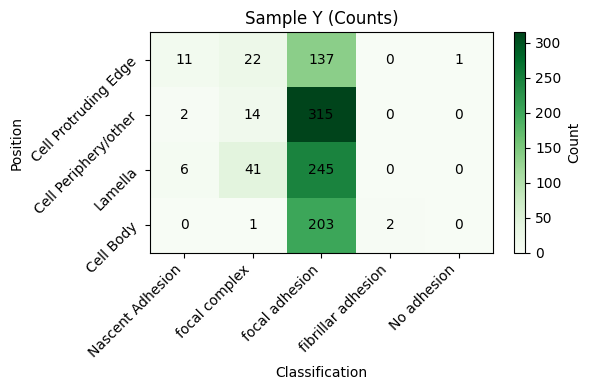

In [182]:

mask = sampled_df["group_ID"] ==1

position_ids = range(len(position_label_order))        # 0..4
fa_ids = range(len(classification_label_order))         # e.g. 0..5

ct = pd.crosstab(
    sampled_df["position_based_pred"][mask],
    sampled_df["FA_class_based_pred"][mask]
)

ct = ct.reindex(
    index=position_ids,
    columns=fa_ids,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Sample Y (Counts)")

# annotate cells
for i in range(ct.shape[0]-1):
    for j in range(ct.shape[1]-1):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

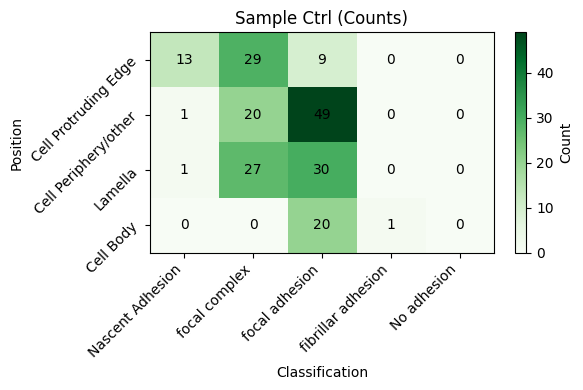

In [183]:

mask = sampled_df["group_ID"] ==0

position_ids = range(len(position_label_order))        # 0..4
fa_ids = range(len(classification_label_order))         # e.g. 0..5

ct = pd.crosstab(
    sampled_df["position_based_pred"][mask],
    sampled_df["FA_class_based_pred"][mask]
)

ct = ct.reindex(
    index=position_ids,
    columns=fa_ids,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct.values[0:4, 0:5], cmap="Greens", aspect="auto")


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Sample Ctrl (Counts)")

# annotate cells
for i in range(ct.shape[0]-1):
    for j in range(ct.shape[1]-1):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [176]:
sampled_df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str',
       'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1',
       'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID', 'y_corner4',
       'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3', 'rand_ty',
       'x_corner1', 'x_corner3', 'movie_partitioned_data_dir', 'y_corner2',
       'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir', 'image_folder',
       'rand_tx', 'filename', 'y_c', 'y_corner1', 'AE_MSE'],
      dtype='object')

In [179]:
sampled_df_clean = sampled_df[['ctrl_y_str',
       'crop_img_filename', 'group_labels', 
       'dist_cell_edge', 'front_flag', 'group',
       'unique_ID', 'FA_class_based_pred', 'position_based_pred',
       'jointlabel_based_pred', 'train_val_flag', 'group_ID', 'y_corner4',
       'x_corner4', 'x_corner2', 'rand_angle', 'y_corner3', 'rand_ty',
       'x_corner1', 'x_corner3', 'movie_partitioned_data_dir', 'y_corner2',
       'filenameID', 'plot_filename', 'x_c', 'movie_plot_dir', 'image_folder',
       'rand_tx', 'filename', 'y_c', 'y_corner1', 'AE_MSE']]

In [181]:
sampled_df_clean.to_csv(os.path.join(root_dir,"ycompFA1000_noadhesion0p001_other1_1200_noholdoff_lesscol.csv"))

In [112]:
root_dir

'/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'

In [107]:
patch_label_df_trainval_MSE.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1_x', 'Unnamed: 0_x_x', 'ctrl_y_str_x',
       'crop_img_filename_x', 'group_labels_x', 'UMAP_d0_x', 'UMAP_d1_x',
       'DBSCAN_labels_x', 'kmeans_labels_x', 'vinculin_intensity_x',
       'pax_intensity_x', 'actin_intensity_x', 'dist_cell_edge', 'front_flag',
       'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6',
       'lat_d7', 'group_x', 'unique_ID', 'FA_class_based_pred',
       'position_based_pred', 'jointlabel_based_pred', 'Unnamed: 0_y_x',
       'crop_img_filename_y', 'train_val_flag', 'group_ID', 'group_y',
       'Unnamed: 0', 'Unnamed: 0_x_y', 'ctrl_y_str_y', 'crop_img_filename',
       'group_labels_y', 'UMAP_d0_y', 'UMAP_d1_y', 'DBSCAN_labels_y',
       'kmeans_labels_y', 'vinculin_intensity_y', 'pax_intensity_y',
       'actin_intensity_y', 'dist_cell_edge_x', 'front_flag_x',
       'Unnamed: 0.1_y', 'Unnamed: 0_y_y', 'y_corner4', 'x_corner4',
       'x_corner2', 'rand_angle', 'y_corner3', 'rand_ty', 'x_corner1',

In [109]:
df = patch_label_df_trainval_MSE

/tmp/ipykernel_790355/161699553.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_790355/161699553.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_790355/161699553.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_790355/161699553.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


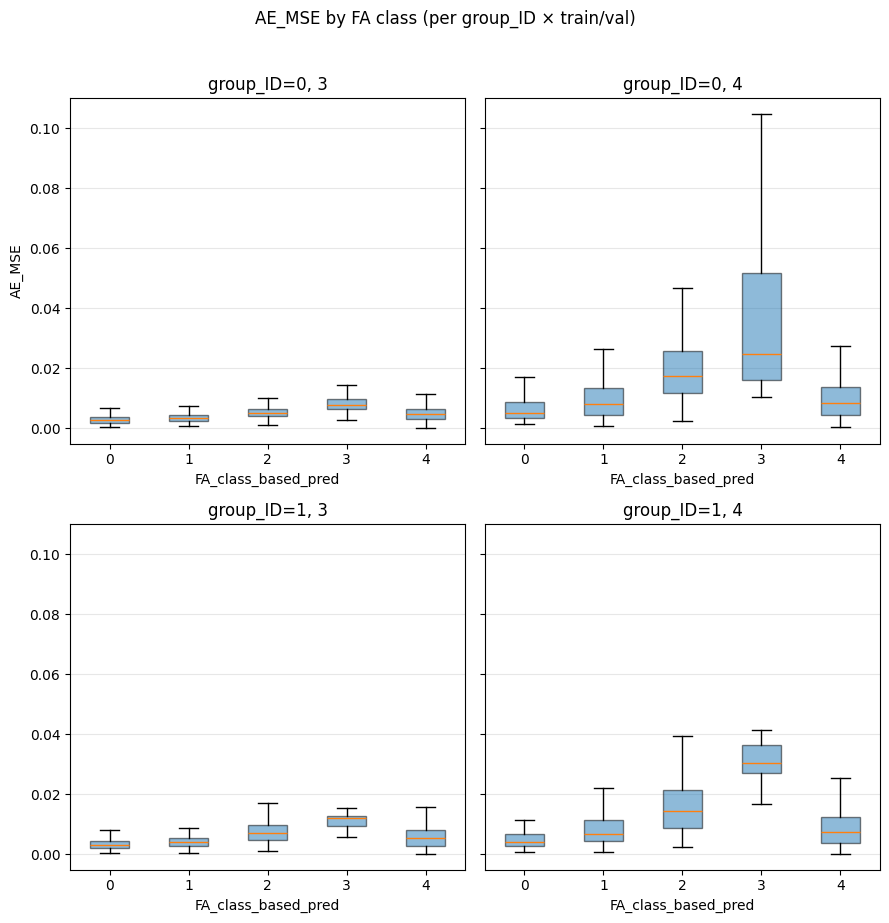

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) select + clean ----
dfp = df[["AE_MSE", "group_ID", "train_val_flag", "FA_class_based_pred"]].copy()
dfp = dfp.dropna(subset=["AE_MSE", "group_ID", "train_val_flag", "FA_class_based_pred"])

dfp["group_ID"] = dfp["group_ID"].astype(int)
dfp["train_val_flag"] = dfp["train_val_flag"].astype(int)

# if FA_class_based_pred is already int ids:
dfp["FA_class_based_pred"] = dfp["FA_class_based_pred"].astype(int)

# orders
group_ids = sorted(dfp["group_ID"].unique())          # e.g. [0, 1]
tv_flags  = sorted(dfp["train_val_flag"].unique())    # e.g. [0, 1]
fa_classes = sorted(dfp["FA_class_based_pred"].unique())  # 5 classes expected

# nice labels for train/val
tv_name = {0: "train", 1: "val"}

# ---- 2) 2x2 figure ----
fig, axes = plt.subplots(
    len(group_ids), len(tv_flags),
    figsize=(4.5*len(tv_flags), 4.5*len(group_ids)),
    sharey=True
)

# axes indexing safety (works even if 1 row/col)
axes = np.array(axes).reshape(len(group_ids), len(tv_flags))

for r, g in enumerate(group_ids):
    for c, tv in enumerate(tv_flags):
        ax = axes[r, c]

        sub = dfp[(dfp["group_ID"] == g) & (dfp["train_val_flag"] == tv)]

        # data: list of arrays, one per FA class
        data = [
            sub.loc[sub["FA_class_based_pred"] == fa, "AE_MSE"].values
            for fa in fa_classes
        ]

        bp = ax.boxplot(
            data,
            labels=[str(fa) for fa in fa_classes],
            patch_artist=True,
            showfliers=False
        )

        # light fill to improve readability (no manual color selection)
        for box in bp["boxes"]:
            box.set_alpha(0.5)

        ax.set_title(f"group_ID={g}, {tv_name.get(tv, tv)}")
        ax.set_xlabel("FA_class_based_pred")
        ax.grid(True, axis="y", alpha=0.3)

axes[0, 0].set_ylabel("AE_MSE")
fig.suptitle("AE_MSE by FA class (per group_ID × train/val)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
mask = patch_label_df_trainval_MSE['FA_class_based_pred']==1

,Unnamed: 0,crop_img_filename,train_val_flag,group_ID,group,unique_ID
0,0,f0023x0752y1008ps32,3,1,ycomp,ycomp-f0023x0752y1008ps32
1,1,f0010x0208y0848ps32,3,1,ycomp,ycomp-f0010x0208y0848ps32
2,2,f0000x0464y0272ps32,3,0,control,control-f0000x0464y0272ps32
3,3,f0030x0400y0848ps32,3,0,control,control-f0030x0400y0848ps32
4,4,f0009x0880y0368ps32,3,0,control,control-f0009x0880y0368ps32
...,...,...,...,...,...,...
23651,23651,f0003x0176y0432ps32,4,1,ycomp,ycomp-f0003x0176y0432ps32
23652,23652,f0013x0752y0496ps32,4,1,ycomp,ycomp-f0013x0752y0496ps32
23653,23653,f0045x0624y0624ps32,4,0,control,control-f0045x0624y0624ps32
23654,23654,f0020x0976y0688ps32,4,0,control,control-f0020x0976y0688ps32


In [92]:
patch_label_df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,...,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,group,unique_ID,FA_class_based_pred,position_based_pred,jointlabel_based_pred
0,0,0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,...,-7.815341,1.760113,32.959721,-21.882824,2.258103,control,control-f0000x0080y0816ps32.tif,2,1,0
1,1,1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,...,5.473682,-1.714877,1.444764,-5.044192,-2.793007,control,control-f0000x0112y0784ps32.tif,4,1,7
2,2,2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134788,1.867131,0,0,...,2.456605,0.941578,6.303121,-6.728461,-7.896038,control,control-f0000x0144y0784ps32.tif,1,1,2
3,3,3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,...,-0.638954,3.322603,22.364613,-18.249426,0.339599,control,control-f0000x0176y0784ps32.tif,2,1,0
4,4,4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,...,4.266151,3.475077,12.175271,-11.814137,-9.985755,control,control-f0000x0240y0752ps32.tif,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,...,4.427641,-0.110387,9.007499,-16.987860,-2.702754,ycomp,ycomp-f0040x0912y0624ps32.tif,4,2,5
23652,23652,23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,...,7.115860,2.850735,12.949064,-10.358782,-3.006688,ycomp,ycomp-f0040x0912y0656ps32.tif,1,1,0
23653,23653,23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,...,1.686419,1.671660,7.410644,-7.135116,-0.333692,ycomp,ycomp-f0040x0912y0688ps32.tif,4,2,7
23654,23654,23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,...,3.669299,-1.798731,8.590202,-13.161478,-6.561848,ycomp,ycomp-f0040x0912y0720ps32.tif,1,1,2


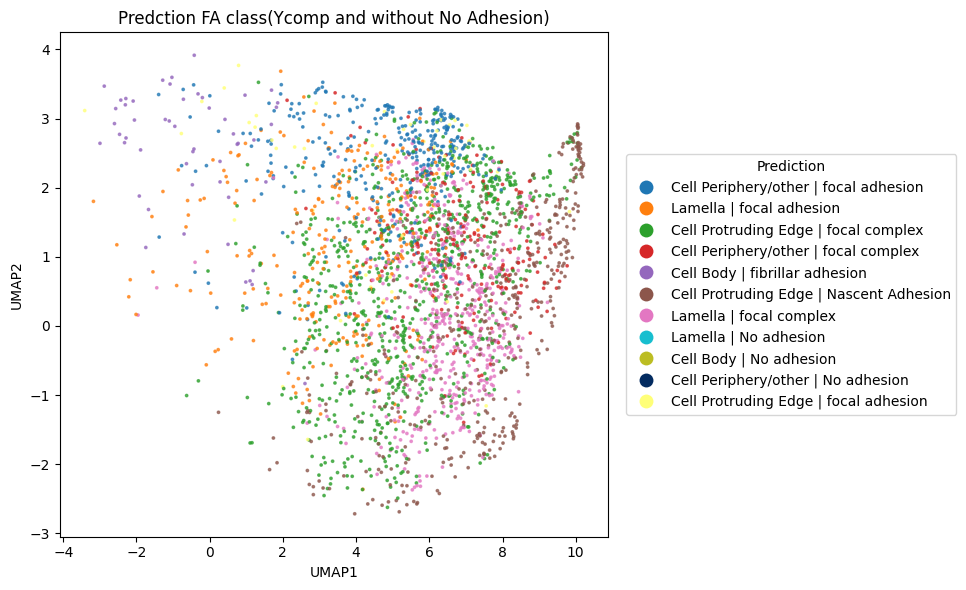

In [89]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), \
                            patch_label_df['group'].values == 'ycomp')

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction FA class(Ycomp and without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=10,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



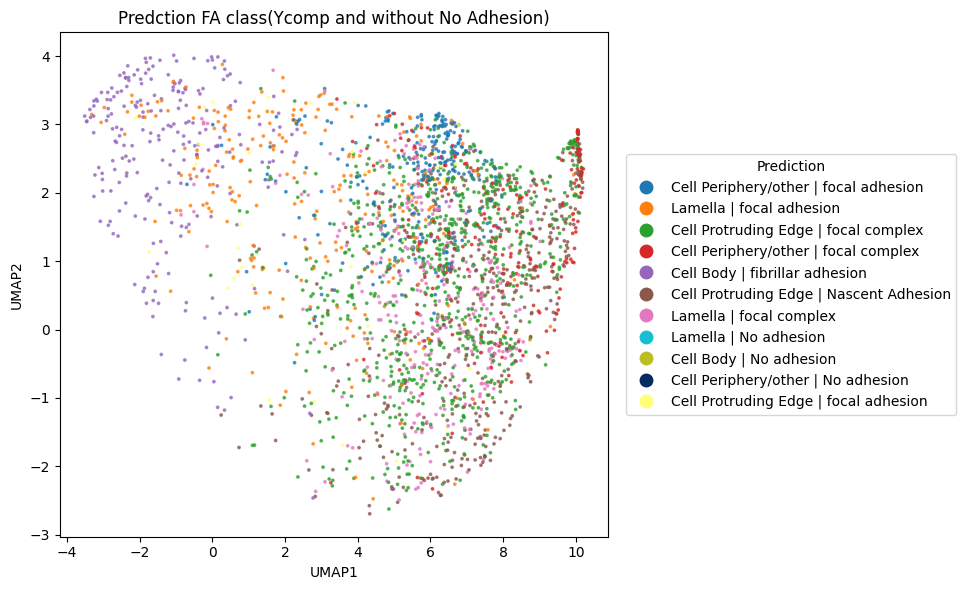

In [43]:
# plot without the  "no adhesion group"
mask = np.logical_and(np.logical_and(np.logical_and(y_jointlabel_all_pred!=9, \
                         y_jointlabel_all_pred!=7),y_jointlabel_all_pred!=8), patch_label_df['group'].values == 'ycomp')

pred_ids = y_jointlabel_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(12, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=3
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predction FA class(Ycomp and without No Adhesion)")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=joint_labels_to_color[label],
        markeredgecolor="none",
        markersize=10,
        label=label
    )
    for label in joint_labels_to_color
]

plt.legend(
    handles=handles,
    title="Prediction",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_clf = LinearDiscriminantAnalysis(
    solver="svd"   # default, good for small-sample cases
)

lda_clf.fit(X_train, y_jointlabel_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [40]:
y_pred_LDA_train = lda_clf.predict(X_train)
y_pred_LDA_val = lda_clf.predict(X_val)


In [41]:
y_pred_LDA_all = lda_clf.predict(X_all)

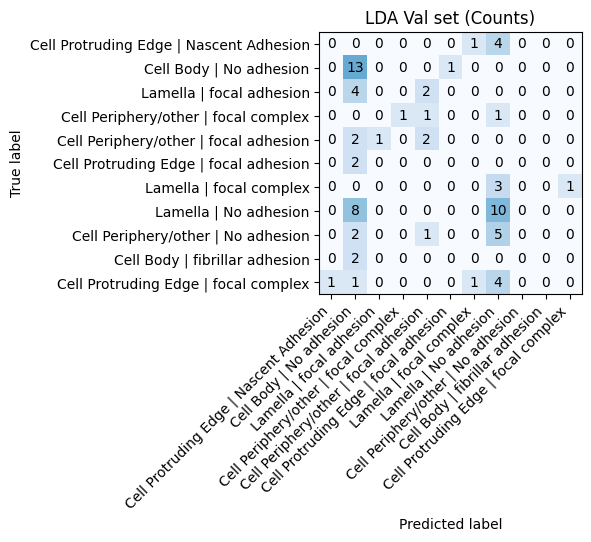

In [42]:

cm = confusion_matrix(y_jointlabel_val, y_pred_LDA_val)
class_names = joint_labels_to_color
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("LDA Val set (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [43]:
lda_2d = LinearDiscriminantAnalysis(
    n_components=2,
    solver="svd"
)

lda_2d.fit(X_train, y_jointlabel_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,2
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [44]:
lda_3d = LinearDiscriminantAnalysis(
    n_components=3,
    solver="svd"
)

lda_3d.fit(X_train, y_jointlabel_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,3
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [45]:
X_lda_all_3d = lda_3d.transform(X_all) 

In [46]:
X_lda_all_3d

array([[ 3.66649687,  4.81254344, -1.03622188],
       [-0.62942025, -0.90667081, -0.14424089],
       [-0.4623587 ,  1.6595634 , -2.63911503],
       ...,
       [-0.01303227, -0.10763345, -0.93845182],
       [-1.24908535,  0.17278095, -0.92663723],
       [-1.41913529,  0.75902067, -0.86631008]])

In [47]:
lat8_margaret_label_121922.columns

Index(['Unnamed: 0', 'unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group'],
      dtype='object')

In [48]:
patch_label_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge', 'front_flag', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3',
       'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7', 'group', 'unique_ID'],
      dtype='object')

In [49]:
X_labeled = lat8_margaret_label_121922[lat_cols].values

X_lda_all_2d = lda_2d.transform(X_all)   
X_lda_train_2d = lda_2d.transform(X_train)   
X_lda_val_2d = lda_2d.transform(X_val)   
X_lda_labeled_2d = lda_2d.transform(X_labeled)   



In [50]:
label_cols = [
    "unique_ID",
    "Position",
    "classification"
]

labels_df = lat8_margaret_label_121922[label_cols].copy()
patch_with_labels = patch_label_df.merge(
    labels_df,
    on="unique_ID",
    how="left"
)
is_labeled = patch_with_labels["Position"].notna()
n_labeled = is_labeled.sum()
n_unlabeled = (~is_labeled).sum()

print(f"Labeled: {n_labeled}")
print(f"Unlabeled: {n_unlabeled}")


Labeled: 389
Unlabeled: 23267


In [51]:
X_lda_labeled_2d.shape

(389, 2)

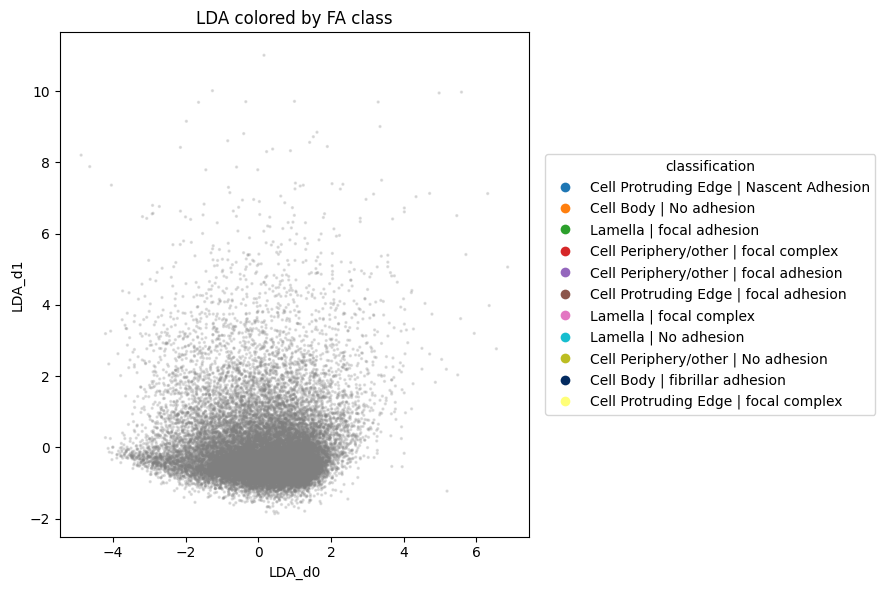

In [52]:
plt.figure(figsize=(9, 6))

plt.scatter(X_lda_all_2d[:,0] , X_lda_all_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    X_lda_labeled_2d[:,0],
    X_lda_labeled_2d[:,1],
    c=lat8_margaret_label_121922["classification"].map(joint_labels_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

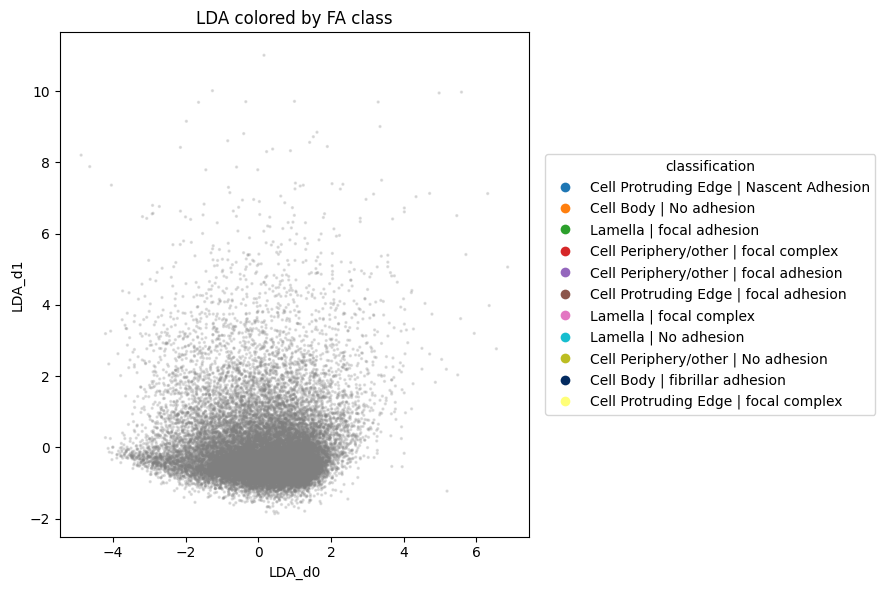

In [53]:
plt.figure(figsize=(9, 6))

plt.scatter(X_lda_all_2d[:,0] , X_lda_all_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    X_lda_labeled_2d[:,0],
    X_lda_labeled_2d[:,1],
    c=lat8_margaret_label_121922["classification"].map(joint_labels_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

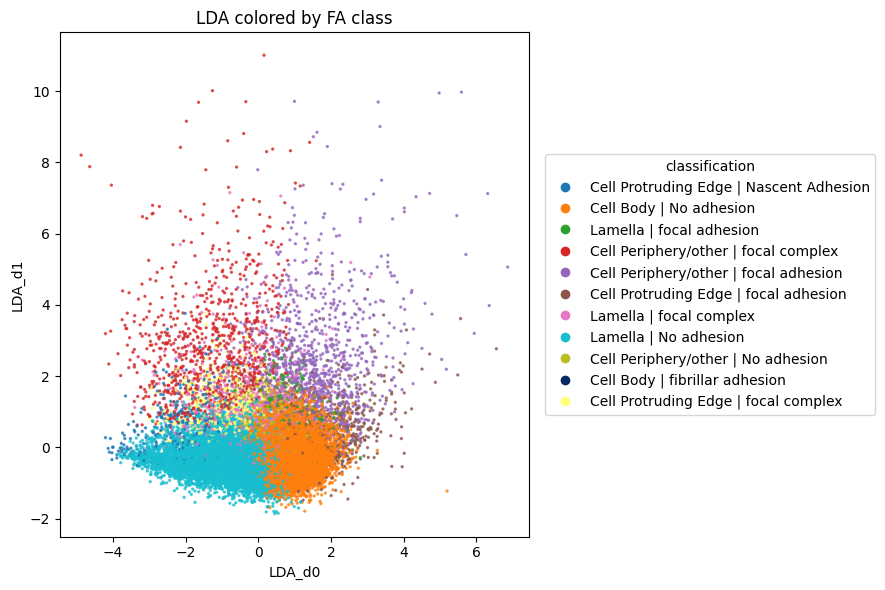

In [54]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

plt.scatter(
    X_lda_all_2d[:, 0],
    X_lda_all_2d[:, 1],
    c=pred_colors,
    s=2,
    alpha=0.7
)

plt.xlabel("LDA_d0")
plt.ylabel("LDA_d1")
plt.title("LDA colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

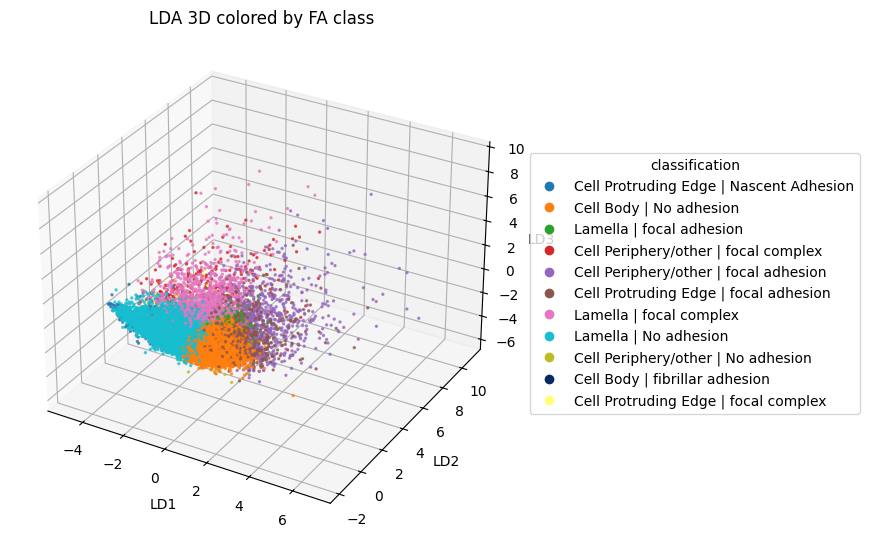

In [55]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_lda_all_3d[:, 0],
    X_lda_all_3d[:, 1],
    X_lda_all_3d[:, 2],
    c=pred_colors,
    s=2,
    alpha=0.7
)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")


plt.title("LDA 3D colored by FA class")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()

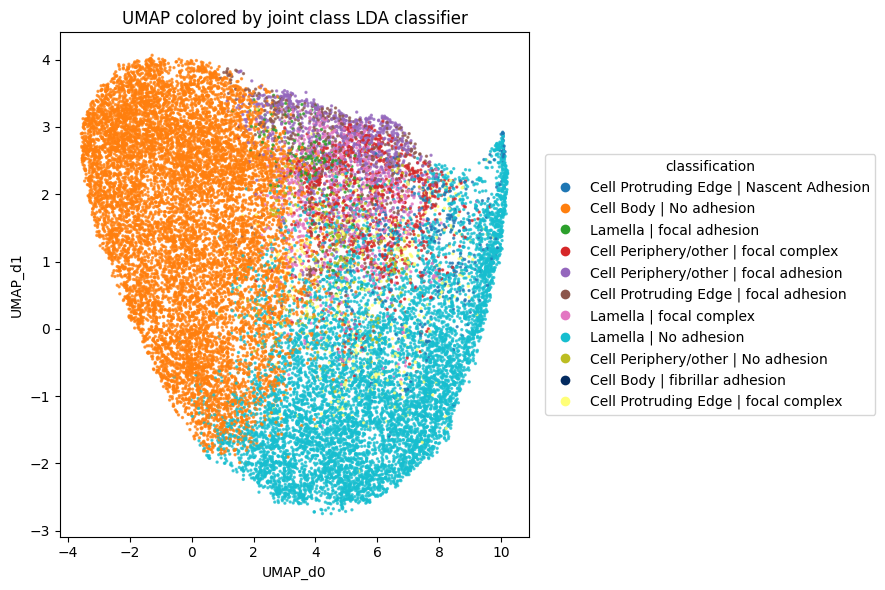

In [60]:
plt.figure(figsize=(9, 6))


pred_colors = [fa_id_to_color[i] for i in y_pred_LDA_all]

plt.scatter(
    latents_lat8_2d[:, 0],
    latents_lat8_2d[:, 1],   
    c=pred_colors,
    s=2,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by joint class LDA classifier")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=joint_labels_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in joint_labels_to_color
]
plt.legend(
    handles=handles,
    title="classification",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()